# EDA

### Notes on the data

Notes were taken directly from the Kaggle source for reference.

- Training data, which includes the target unit_sales by date, store_nbr, and item_nbr and a unique id to label rows.
- The target unit_sales can be integer (e.g., a bag of chips) or float (e.g., 1.5 kg of cheese). This means units differ by products and can only be plotted together as relative total volume over time, not as literal unit counts. 
- Negative values of unit_sales represent returns of that particular item.
- The onpromotion column tells whether that item_nbr was on promotion for a specified date and store_nbr. Approximately 16% of the onpromotion values in this file are NaN.
- The training data does not include rows for items that had zero unit_sales for a store/date combination. There is no information as to whether or not the item was in stock for the store on the date.
- A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was transferred from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

## Findings

- Total daily sales trends upward with increasing variance. 
- There are noticeable dips in total daily sales at the end of each year, which could reflect store closures during the holidays.
- The distribution of units sold is heavily right-skewed, suggesting that it may be necessary to model in log format.
- The most frequent number of units sold is 0, which tells us that many store/family combinations do not sell any units on most days.
- Weekends (Saturdays and Sundays) show the highest average units sold by day of the week. This pattern holds across product families, except for the liqour, wine and beer family, which shows highest sales on Saturday, but very low sales on Sunday.
- A heatmap confirms that Saturdays and Sundays are the highest sale days across families, with the exception of Liqour. An ACF plot confirms that a 7-week seasonality period is present in the data from the spikes that are apparent every 7 days.
- December shows the highest average units sold by month.
- The STL decomposition shows the trend moving upward as the years progress, the variance in the seasonality plot becoming greater over time, and the variance in the residuals staying relatively steady around the mean over time, but with a few noticeable outliers which increase in their variance from the mean over time.
- Items on promotion sell 7.2x more on average.
- We see a directional index of +5 units sold on paydays versus non-paydays. Units are not directly comparable across product families, but this indicates a directional increase in overall volume of units sold on paydays.
- The Grocery and Beverages product families have the highest total unit sales.
- The Earthquake in 2016 caused a visibly higher spike in units sold.

## Imports

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
# Check that make_dataset.py has been run and the processed data is available
train = pd.read_parquet("../data/processed/train.parquet")

print("Rows:", f"{len(train):,}")
print("Stores:", train.store_nbr.nunique())                             # should be 54
print("Families:", train.family.nunique())                              # should be 33
print("Series:", train.store_nbr.nunique() * train.family.nunique())    # should be 1,782) 
print("Date range:", train.date.min().date(), "->", train.date.max().date())
print("Missing sales:", train.sales.isna().sum())
print("Zero-sales rows %:", (train.sales == 0).mean().round(3))

Rows: 3,000,888
Stores: 54
Families: 33
Series: 1782
Date range: 2013-01-01 -> 2017-08-15
Missing sales: 0
Zero-sales rows %: 0.313


In [3]:
P = "../data/processed/"
stores = pd.read_parquet(P + "stores.parquet")
oil = pd.read_parquet(P + "oil.parquet")
holidays = pd.read_parquet(P + "holidays.parquet")

df = (train
      .merge(stores, on="store_nbr", how="left")
      .merge(oil, on="date", how="left"))

df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day"] = df["date"].dt.day

In [4]:
assert len(df) == len(train) # merge sanity check

In [5]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,day_of_week,month,year,day
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Tuesday,1,2013,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Tuesday,1,2013,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Tuesday,1,2013,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,Tuesday,1,2013,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,Tuesday,1,2013,1


## Total Units Sold by Day

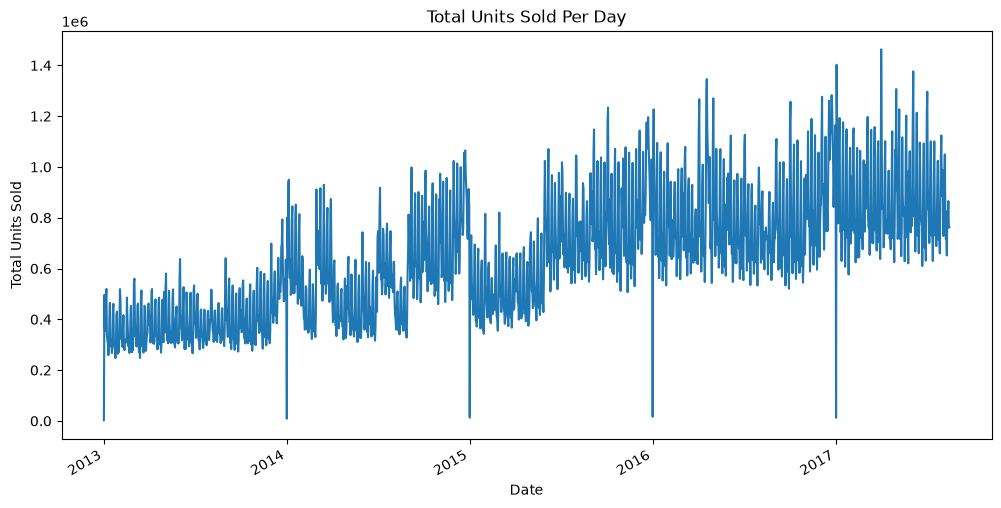

In [6]:
daily_sales = df.groupby("date")["sales"].sum()
daily_sales.plot(figsize=(12,6), 
                 title="Total Units Sold Per Day")
plt.ylabel("Total Units Sold")
plt.xlabel("Date")
plt.show()

## Distribution of Units Sold

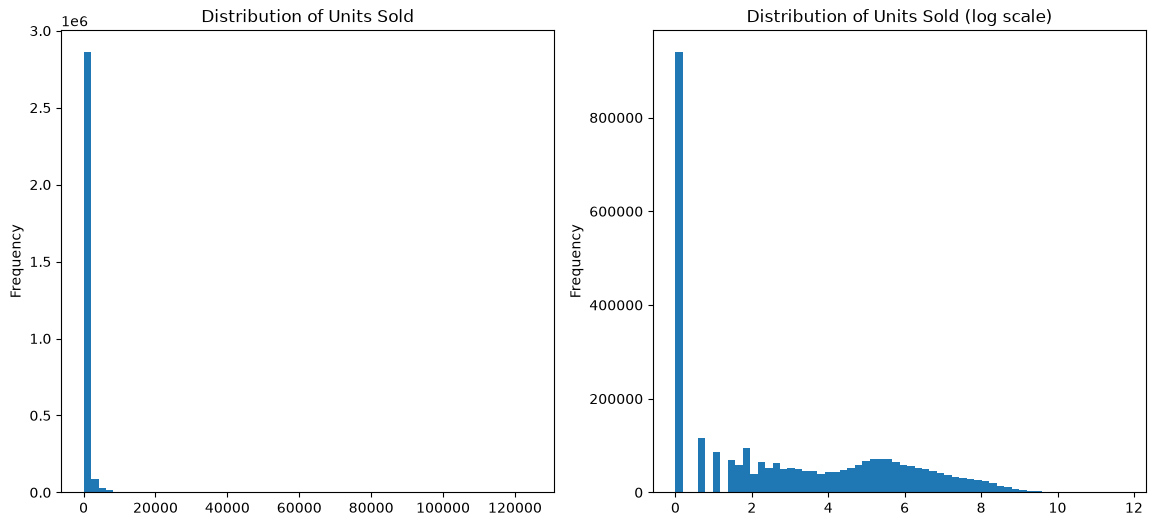

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

df["sales"].plot.hist(ax=ax[0], bins=60)
ax[0].set_title("Distribution of Units Sold")

np.log1p(df["sales"]).plot.hist(ax=ax[1], bins=60)
ax[1].set_title("Distribution of Units Sold (log scale)")

plt.show()

## Average Units Sold by Day of the Week and Month

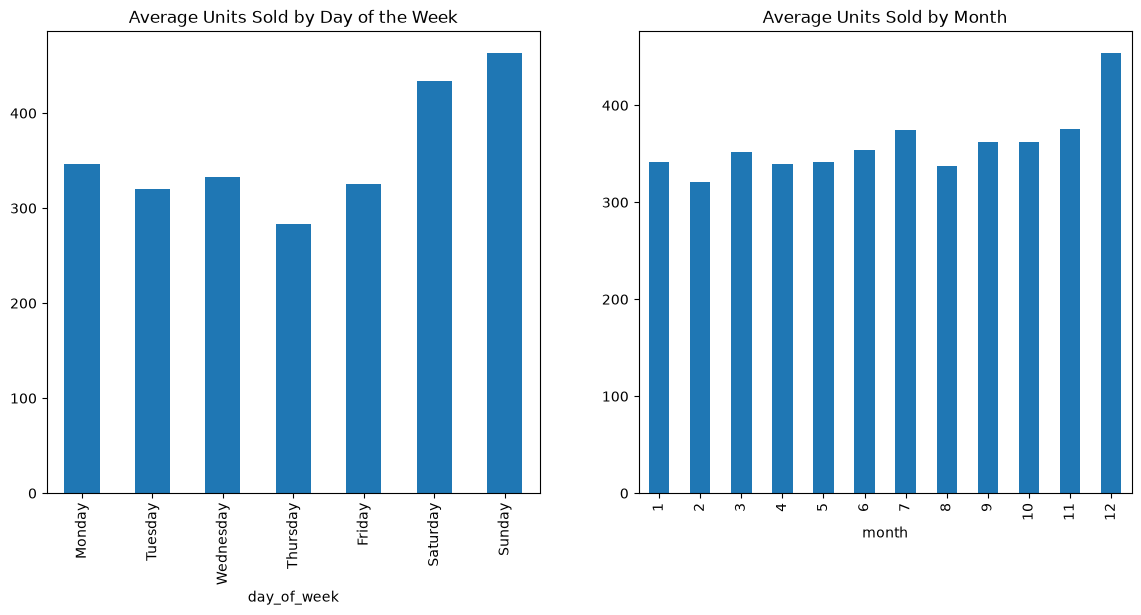

In [8]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("day_of_week")["sales"].mean().reindex(order).plot(kind="bar", ax=ax[0])
ax[0].set_title("Average Units Sold by Day of the Week")

df.groupby("month")["sales"].mean().plot(kind="bar", ax=ax[1])
ax[1].set_title("Average Units Sold by Month")

plt.show()

### Average units sold by family by day of the week

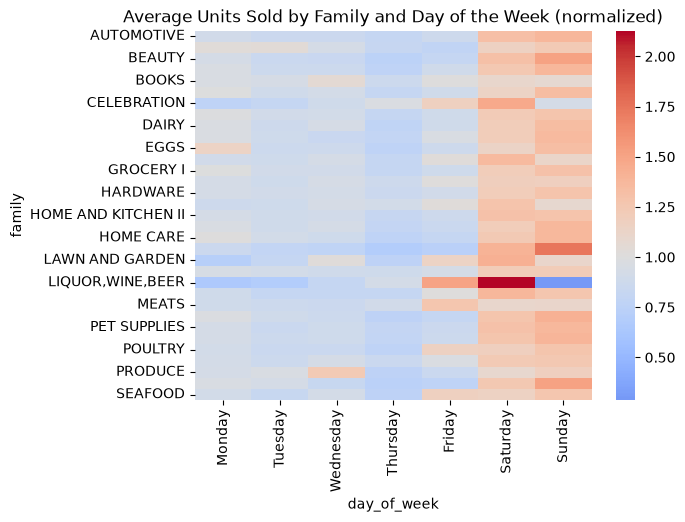

In [9]:
family_dow = df.pivot_table(index='family', columns='day_of_week', values='sales', aggfunc='mean')
family_dow = family_dow.div(family_dow.mean(axis=1), axis=0)
sns.heatmap(family_dow[order], cmap="coolwarm", center=1)
plt.title("Average Units Sold by Family and Day of the Week (normalized)")

plt.show()

## STL Decomposition

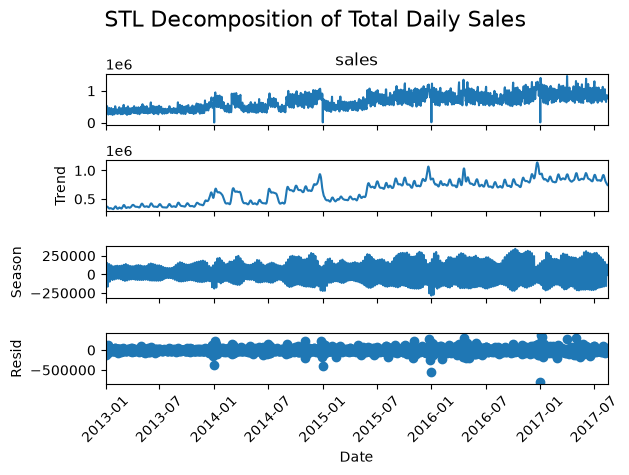

In [10]:
res = STL(daily_sales.asfreq("D").interpolate(), period=7).fit()
res.plot()

plt.suptitle("STL Decomposition of Total Daily Sales", fontsize=16)
plt.xlabel("Date")
plt.xticks(rotation=45)

plt.tight_layout()

## ACF Plot

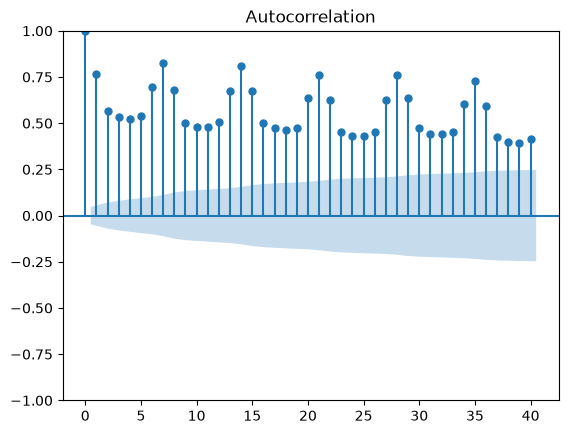

In [11]:
plot_acf(daily_sales.asfreq("D").interpolate(), lags=40)
plt.show()

## Effect of Promotions on Units Sold

In [12]:
promo = df.assign(promo=df.onpromotion > 0).groupby("promo")["sales"].mean()
print(promo)
print(f"{promo[True] / promo[False]:.1f}x more units sold when on promotion.")

promo
False     158.246674
True     1137.693726
Name: sales, dtype: float32
7.2x more units sold when on promotion.


## Effect of Paydays on Units Sold

In [13]:
df["payday"] = (df.day == 15) | (df.date.dt.is_month_end)
print(df.groupby('payday')['sales'].mean())

payday
False    357.442719
True     362.494904
Name: sales, dtype: float32


## Effect of Holidays on Units Sold

In [14]:
# Find the real holidays based on instructions in data description
h = holidays.copy()
real_holiday = (
    ((h["type"] == "Holiday") & (~h["transferred"])) | (h["type"].isin(["Transfer", "Bridge", "Additional"]))
)
h["is_real_holiday"] = real_holiday

In [15]:
# Find the national holidays that effect everyone
national_holidays = set(h.loc[h.is_real_holiday & (h.locale == "National"), "date"])
df["natl_holiday"] = df["date"].isin(national_holidays)

# Find the local holidays and match them to stores
loc = h[h.is_real_holiday & (h.locale != "National")]
loc_pairs = set(zip(loc["date"], loc["locale_name"]))
df["local_holiday"] = (
    df.apply(lambda r: (r["date"], r["city"]) in loc_pairs or (r["date"], r["state"]) in loc_pairs, axis=1) # can be vectorized later on when defining features for modeling
)
df["is_holiday"] = df["natl_holiday"] | df["local_holiday"]

print(df.groupby("is_holiday")["sales"].mean())

is_holiday
False    354.277130
True     423.469849
Name: sales, dtype: float32


## Top Families by Units Sold

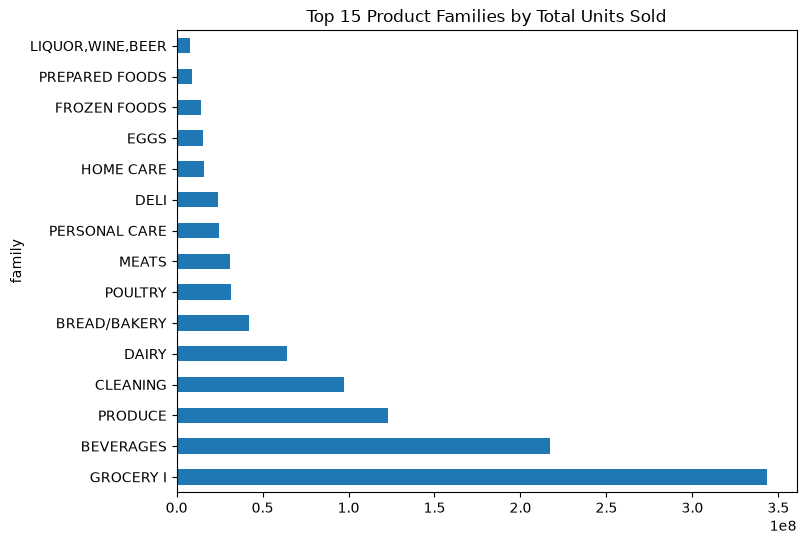

In [16]:
top = df.groupby("family")["sales"].sum().sort_values(ascending=False)
top.head(15).plot(kind="barh", figsize=(8,6), title="Top 15 Product Families by Total Units Sold")

plt.show()

## Percent of Items in a Perishable Family out of Total Units

In [17]:
PERISHABLE = ["PRODUCE","DAIRY","MEATS","POULTRY","SEAFOOD","DELI", "BREAD/BAKERY","EGGS","FROZEN FOODS","PREPARED FOODS"]

df["perishable"] = df["family"].isin(PERISHABLE)
print(f"{df.perishable.mean():.1%} of units are perishable.")

30.3% of units are perishable.


## Effect of 2016 Earthquake

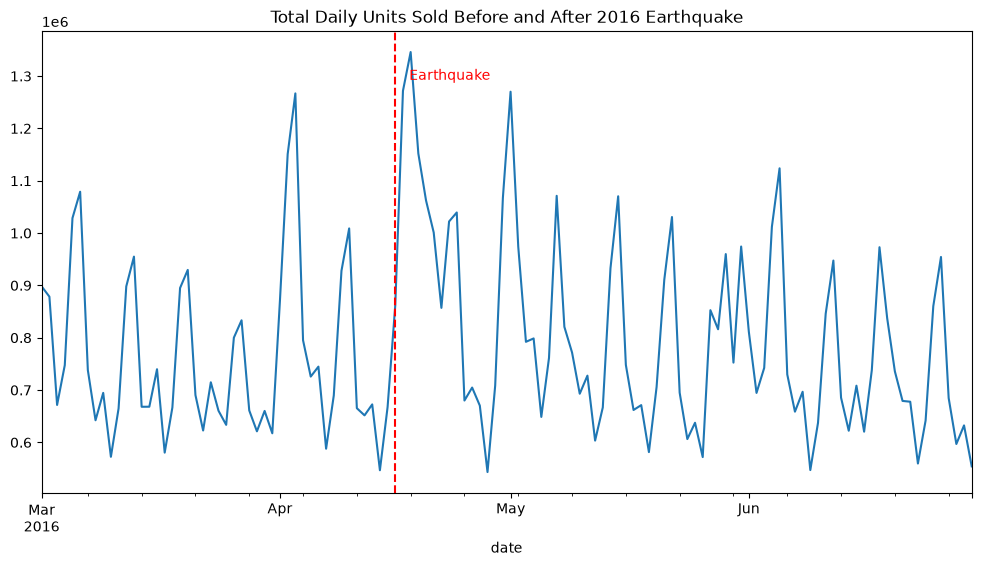

In [18]:
earthquake = daily_sales.loc["2016-03-01":"2016-06-30"]
ax = earthquake.plot(figsize=(12,6))
ax.axvline(pd.Timestamp("2016-04-16"), color="red", linestyle="--")
ax.annotate("Earthquake", xy=(pd.Timestamp("2016-04-16"), earthquake.max()), xytext=(10,-20), textcoords="offset points", color="red")
ax.set_title("Total Daily Units Sold Before and After 2016 Earthquake")
plt.show()